# Chapter 15 - Understanding Strategy Risk

## Preparation

In [1]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join('..')))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, moment, skew, kurtosis
from IPython.display import Image, display
from itertools import product

from utils.ef3m import M2N, rawMoment
from utils.backtest_stats import get_psr
from utils.synthetic import simulate_ou_process

%matplotlib inline
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = 16,6

## 1. A portfolio manager intends to launch a strategy that targets an annualized SR of 2. Bets have a precision rate of 60%, with weekly frequency. The exit conditions are 2% for profit-taking, and –2% for stop-loss.

### a. Is this strategy viable?

In [2]:
def annualized_symmetric_payouts(p, n):
    return (2 * p - 1) / (2 * np.sqrt(p * (1 - p))) * np.sqrt(n)

def annualized_asymmetric_payouts(p, n, pt, sl):
    return ((pt - sl) * p + sl) / ((pt - sl) * np.sqrt(p * (1 - p))) * np.sqrt(n)

p = 0.6
n = 52

print(f"The annualized symmetric payout with precision {p} and frequency {n} is {annualized_symmetric_payouts(p, n)}")

The annualized symmetric payout with precision 0.6 and frequency 52 is 1.4719601443879742


Since the symmetric payout is 1.47, it is not viable to get an annualized SR of 2.

### b. Ceteris paribus, what is the required precision rate that would make the strategy profitable?

In [3]:
def symmetric_precision(sr, n):
    inner_term = n + sr ** 2
    a = 4 * inner_term
    b = -4 * inner_term
    c = n
    return (-b + np.sqrt(b ** 2 - 4 * a * c)) / (2 * a)

def asymmetric_precision(sr, n, pt, sl):
    a = (n + sr ** 2) * (pt - sl) ** 2
    b = (2 * n * sl - sr ** 2 * (pt - sl)) * (pt - sl)
    c = n * sl ** 2
    return (-b + np.sqrt(b ** 2 - 4 * a * c)) / (2 * a)

sr = 2
n = 52

print(f"The required precision rate that would make the strategy profitable for an annualized SR of {sr} and a frequency of {n} is {symmetric_precision(sr, n):4f}")

The required precision rate that would make the strategy profitable for an annualized SR of 2 and a frequency of 52 is 0.633631


### c. For what betting frequency is the target achievable?

In [4]:
def symmetric_frequency(sr, p):
    return int((4 * sr**2 * p * (1 - p)) / (2 * p - 1)**2)

sr = 2
p = 0.6

print(f"The required betting frequency that would make the strategy profitable for an annualized SR of {sr} and a precision rate of {p} is {symmetric_frequency(sr, p)}")

The required betting frequency that would make the strategy profitable for an annualized SR of 2 and a precision rate of 0.6 is 96


### d. For what profit-taking threshold is the target achievable?

In [5]:
def asymmetric_profit_taking(sr, sl, p, n):
    inner_term = sr * np.sqrt(p * (1 - p)) - np.sqrt(n) * p
    return (sl * (np.sqrt(n) + inner_term)) / inner_term

sr = 2
sl = -2
p = 0.6
n = 52

print(f"The required profit-taking threshold that would make the strategy profitable \nfor an annualized SR of {sr}, a stop-loss of {sl}, a precision rate of {p}, and a frequency of {n} is {asymmetric_profit_taking(sr, sl, p, n):4f}")

The required profit-taking threshold that would make the strategy profitable 
for an annualized SR of 2, a stop-loss of -2, a precision rate of 0.6, and a frequency of 52 is 2.309168


### e. What would be an alternative stop-loss?

In [6]:
def asymmetric_stop_loss(sr, pt, p, n):
    inner_term = sr * np.sqrt(p * (1 - p)) - np.sqrt(n) * p
    return (pt * inner_term) / (np.sqrt(n) + inner_term)

sr = 2
pt = 2
p = 0.6
n = 52

print(f"The required stop-loss threshold that would make the strategy profitable \nfor an annualized SR of {sr}, a profit-taking threshold of {pt}, a precision rate of {p}, and a frequency of {n} is {asymmetric_stop_loss(sr, pt, p, n):4f}")

The required stop-loss threshold that would make the strategy profitable 
for an annualized SR of 2, a profit-taking threshold of 2, a precision rate of 0.6, and a frequency of 52 is -1.732226


## 2. Following up on the strategy from exercise 1.

### a. What is the sensitivity of SR to a 1% change in each parameter?

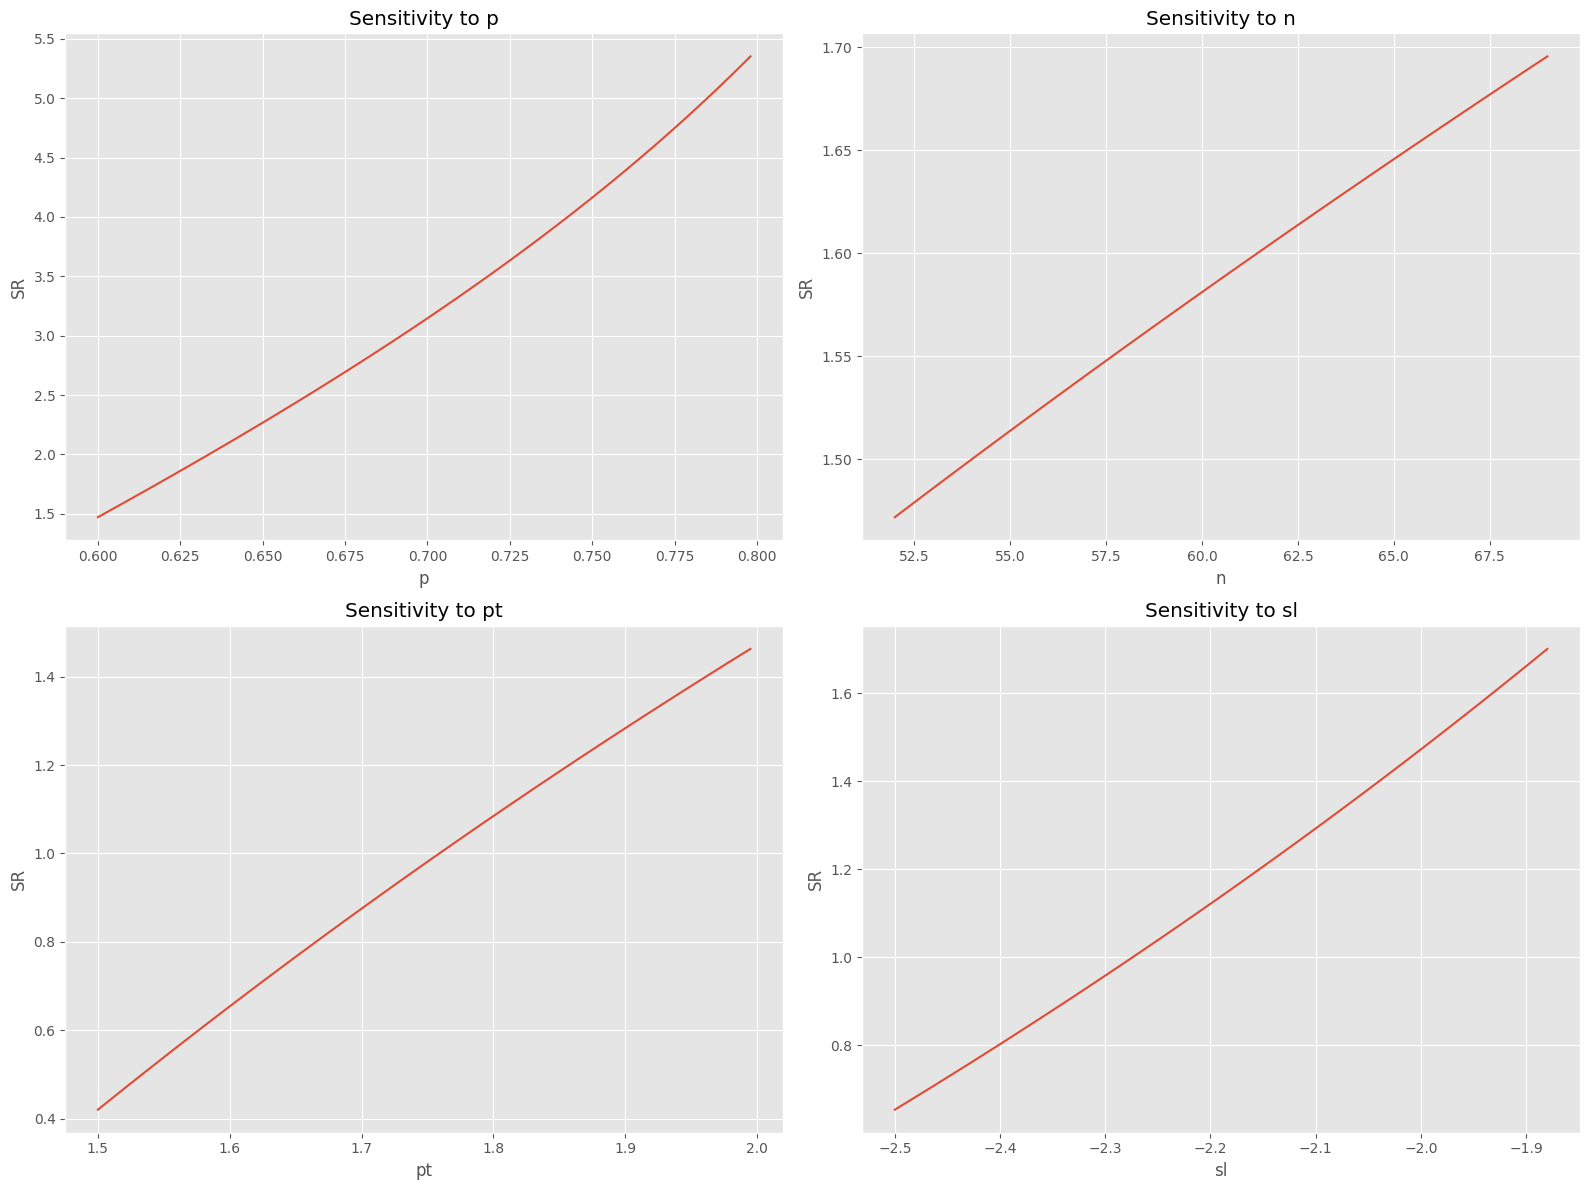

In [7]:
# There are p, n, pt, sl parameters to consider.
p = 0.6
n = 52
pt = 2
sl = -2

percentage_diff = 1.33

# p
p_changes = np.linspace(0.6, 0.6 * percentage_diff, 100)
sr_list_with_p_changes = []

for new_p in p_changes:
    sr_list_with_p_changes.append(annualized_asymmetric_payouts(new_p, n, pt, sl))

# n
n_changes = np.linspace(52, int(52 * percentage_diff), 100)
sr_list_with_n_changes = []

for new_n in n_changes:
    sr_list_with_n_changes.append(annualized_asymmetric_payouts(p, new_n, pt, sl))

# pt
pt_changes = np.linspace(1.5, 1.5 * percentage_diff, 100)
sr_list_with_pt_changes = []

for new_pt in pt_changes:
    sr_list_with_pt_changes.append(annualized_asymmetric_payouts(p, n, new_pt, sl))

# sl
sl_changes = np.linspace(-2.5, -2.5 / percentage_diff, 100)
sr_list_with_sl_changes = []

for new_sl in sl_changes:
    sr_list_with_sl_changes.append(annualized_asymmetric_payouts(p, n, pt, new_sl))


# Now plot them in a 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

axs[0, 0].plot(p_changes, sr_list_with_p_changes)
axs[0, 0].set_title('Sensitivity to p')
axs[0, 0].set_xlabel('p')
axs[0, 0].set_ylabel('SR')

axs[0, 1].plot(n_changes, sr_list_with_n_changes)
axs[0, 1].set_title('Sensitivity to n')
axs[0, 1].set_xlabel('n')
axs[0, 1].set_ylabel('SR')

axs[1, 0].plot(pt_changes, sr_list_with_pt_changes)
axs[1, 0].set_title('Sensitivity to pt')
axs[1, 0].set_xlabel('pt')
axs[1, 0].set_ylabel('SR')

axs[1, 1].plot(sl_changes, sr_list_with_sl_changes)
axs[1, 1].set_title('Sensitivity to sl')
axs[1, 1].set_xlabel('sl')
axs[1, 1].set_ylabel('SR')

plt.tight_layout()
plt.show()

### b. Given these sensitivities, and assuming that all parameters are equally hard to improve, which one offers the lowest hanging fruit?

In [22]:
std_p_changes = np.std(sr_list_with_p_changes)
std_n_changes = np.std(sr_list_with_n_changes)
std_pt_changes = np.std(sr_list_with_pt_changes)
std_sl_changes = np.std(sr_list_with_sl_changes)

std_list = [std_p_changes, std_n_changes, std_pt_changes, std_sl_changes]
changes = ["p", "n", "pt", "sl"]

for i in range(len(std_list)):
    print(f"The standard deviation of the SR changes for {changes[i]} is {std_list[i]}")

print(f"The parameter with the highest standard deviation is {changes[np.argmax(std_list)]}")


The standard deviation of the SR changes for p is 1.1134849589161027
The standard deviation of the SR changes for n is 0.06515100313437695
The standard deviation of the SR changes for pt is 0.30354305337723786
The standard deviation of the SR changes for sl is 0.30455701481859254
The parameter with the highest standard deviation is p


In this case, improving precision p is the lowest hanging fruit because a 1% increase in p raises SR much more than a 1% increase in n, pt, or sl.

### c. Does changing any of the parameters in exercise 1 impact the others? For example, does changing the betting frequency modify the precision rate, etc.?

Yes. Conditional on target SR, the parameters trade off against each other. In practice they are also behaviorally linked: changing thresholds can alter precision and effective frequency.

## 3. Suppose a strategy that generates monthly bets over two years, with returns following a mixture of two Gaussian distributions. The first distribution has a mean of –0.1 and a standard deviation of 0.12. The second distribution has a mean of 0.06 and a standard deviation of 0.03. The probability that a draw comes from the first distribution is 0.15.

### a. Following López de Prado and Peijan [2004] and López de Prado and  Foreman [2014], derive the first four moments for the mixture's returns.

In [9]:
mean_1 = -0.1
std_1 = 0.12

mean_2 = 0.06
std_2 = 0.03

p = 0.15
n_obs = 2 * 12

def mix_gaussian_returns(mean_1, std_1, mean_2, std_2, p, n_obs):
    returns_1 = np.random.normal(mean_1, std_1, size=int(n_obs * p))
    returns_2 = np.random.normal(mean_2, std_2, size=n_obs - returns_1.shape[0])
    all_returns = np.concatenate([returns_1, returns_2])
    return np.random.permutation(all_returns)

returns = mix_gaussian_returns(mean_1, std_1, mean_2, std_2, p, n_obs)

centered_returns_moments = [moment(returns, moment=i) for i in range(1, 5)]

for i, mnt in enumerate(centered_returns_moments):
    print(f"E[r^{i+1}] = {mnt}")

E[r^1] = 0.0
E[r^2] = 0.007071004252665584
E[r^3] = -0.0012875110071102053
E[r^4] = 0.0005028406857882116


In [10]:
# Calculate raw moments from centered moments
raw_moments = rawMoment(central_moments=centered_returns_moments, dist_mean=returns.mean())
for i, mnt in enumerate(raw_moments):
    print(f"E_Raw[r^{i+1}] = {mnt}")

E_Raw[r^1] = 0.05098154327493321
E_Raw[r^2] = 0.009670122007359472
E_Raw[r^3] = -7.353184490910985e-05
E_Raw[r^4] = 0.0003573091425669242


### b. What is the annualized SR?

In [11]:
mean = raw_moments[0]
variance = raw_moments[1] - mean ** 2

annualized_sr = mean / np.sqrt(variance) * np.sqrt(12)
print(f"The annualized SR is {annualized_sr}")

The annualized SR is 2.100211594699573


### c. Using those moments, compute PSR[1] (see Chapter 14). At a 95% confidence level, would you discard this strategy?

In [12]:
psr = get_psr(annualized_sr / np.sqrt(12), skew(returns), kurtosis(returns), 24, target_sr=1 / np.sqrt(12))
print(f"The PSR[1] is {psr}")

The PSR[1] is 0.8157253065416115


We should discard this strategy, as the probability that our SR is greater than the benchmark SR* is 0.86, which is below the confidence level.

## 4. Using Snippet 15.5, compute $P[p < p_{\theta^* = 1}]$ for the strategy described in exercise 3. At a significance level of 0.05, would you discard this strategy? Is this result consistent with PSR[θ*]?

In [13]:
def prob_failure(returns, n, target_sr):
    # Derive probability that the strategy may fail
    positive_returns_mean, negative_returns_mean = returns[returns > 0].mean(), returns[returns <= 0].mean()
    p = returns[returns > 0].shape[0] / float(returns.shape[0])
    thresP = asymmetric_precision(target_sr, n, positive_returns_mean, negative_returns_mean)
    risk = norm.cdf(thresP, p, p * (1 - p))

    return risk

p_failure = prob_failure(returns, 24, 1)

print(f"The probability that the strategy may fail is {p_failure}")

The probability that the strategy may fail is 0.05726997434609904


Since the probability that this strategy may fail for a given benchmark SR* = 1 is greater than 0.05, we will discard this strategy. The result is consistent with the PSR[θ*].

However, since we only got 24 observations, the fact that the pdf is gaussian may not hold due to the lack of enough samples (so central limit theorem may not hold).

## 5. In general, what result do you expect to be more accurate, PSR[θ*] or $P[p < p_{\theta^* = 1}]$? How are these two methods complementary? 

I expect PSR[θ*] to be moer accurate, since it removes inflation effect caused by short series with skewed and fat-tailed returns. In our case, our series is very short that there are only 24 observations. Besides, our implementation of $P[p < p_{\theta^* = 1}]$ assumes gaussian pdf, which may not hold true with small number of observations.

## 6. Re-examine the results from Chapter 13, in light of what you have learned in this chapter.

### a. Does the asymmetry between profit taking and stop-loss thresholds in OTRs make sense?

Yes. Since both the profit taking and the stop loss thresholds will affect the SR in their own way, and they will also affect other parameters. For instance, in our 1e, we can see that in order to achieve a SR of 2 with profit taking of 2, we will need a stop loss of -1.73, which is not symmetric.

Besides, if we consider the symmetric thresholds, then those thresholds will not affect the SR, which does not make sense.

### b. What is the range of p implied by Figure 13.1, for a daily betting frequency?

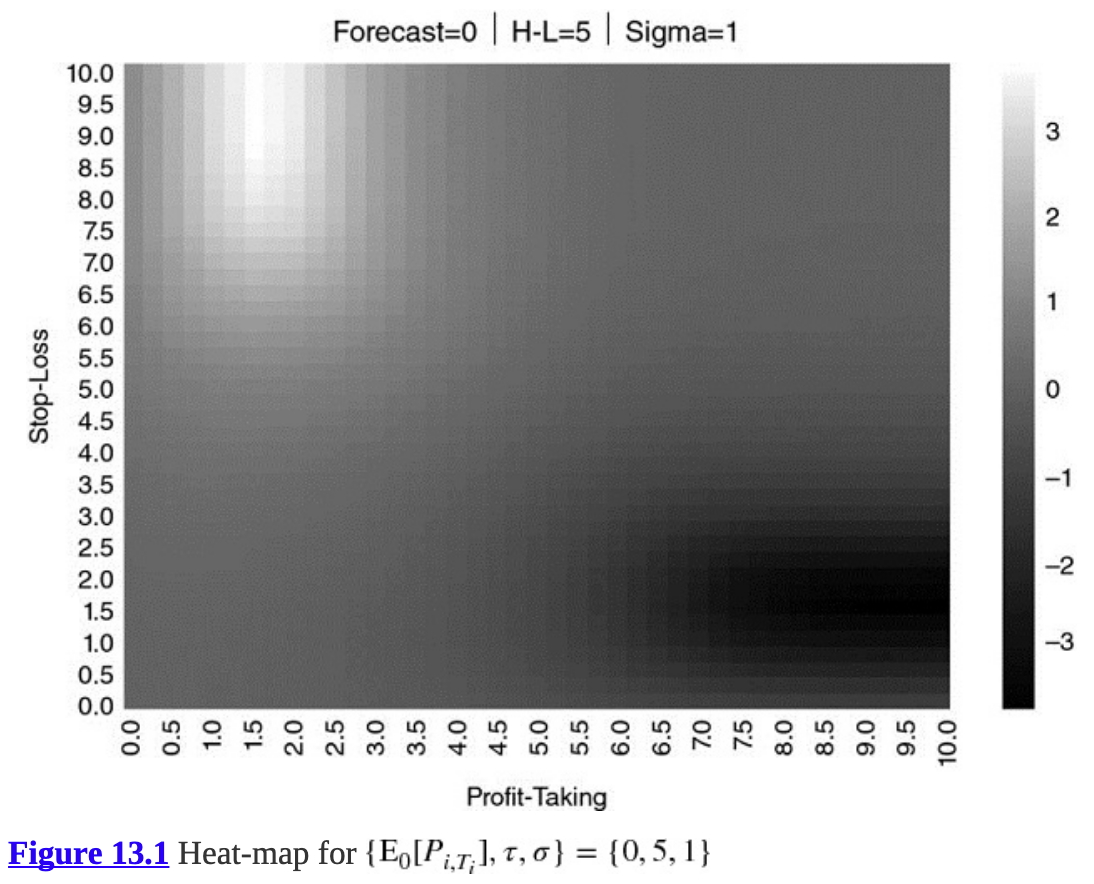

In [14]:
display(Image(filename='fig_13_1.png', width=600))

In [15]:
pt_ranges = np.arange(0.0, 10.5, 0.5)
sl_ranges = np.arange(0.0, 10.5, 0.5)

n = 252

coeffs = {
    "hl": 5,
    "forecast": 0,
    "sigma": 1,
}
results = simulate_ou_process(coeffs, iterations=1e5, max_hp=100, r_pt=pt_ranges, r_slm=sl_ranges, seed=0)
sr_results = [res[-1] for res in results]

Sweep (r_pt, r_slm) pairs: 100%|██████████| 441/441 [09:57<00:00,  1.35s/it]


In [16]:
p_list = []
pt_sl_pairs = []

for i, comb_ in enumerate(product(pt_ranges, sl_ranges)):
    new_p = asymmetric_precision(sr_results[i], n, comb_[0], -comb_[1])
    if not np.isnan(new_p):
        p_list.append(new_p)
        pt_sl_pairs.append((comb_[0], -comb_[1]))
    else:
        print(f"The precision is NaN for pt = {comb_[0]} and sl = {-comb_[1]}")

lowest_p = np.min(p_list)
lowest_p_index = p_list.index(lowest_p)
highest_p = np.max(p_list)
highest_p_index = p_list.index(highest_p)

print(f"The range of p implied by Figure 13.1, for a daily betting frequency, is {lowest_p} to {highest_p}")
print(f"The corresponding pt and sl values are {(pt_sl_pairs[lowest_p_index])} and {pt_sl_pairs[highest_p_index]}")

The precision is NaN for pt = 0.0 and sl = -0.0
The range of p implied by Figure 13.1, for a daily betting frequency, is 1.3795462898047652e-07 to 1.0000000020614892
The corresponding pt and sl values are (np.float64(0.5), np.float64(-0.0)) and (np.float64(0.0), np.float64(-0.5))


/var/folders/jz/5x8l_3b512v8q13q14lhl6nc0000gn/T/ipykernel_57524/3301175551.py:12: RuntimeWarning: invalid value encountered in scalar divide
  return (-b + np.sqrt(b ** 2 - 4 * a * c)) / (2 * a)


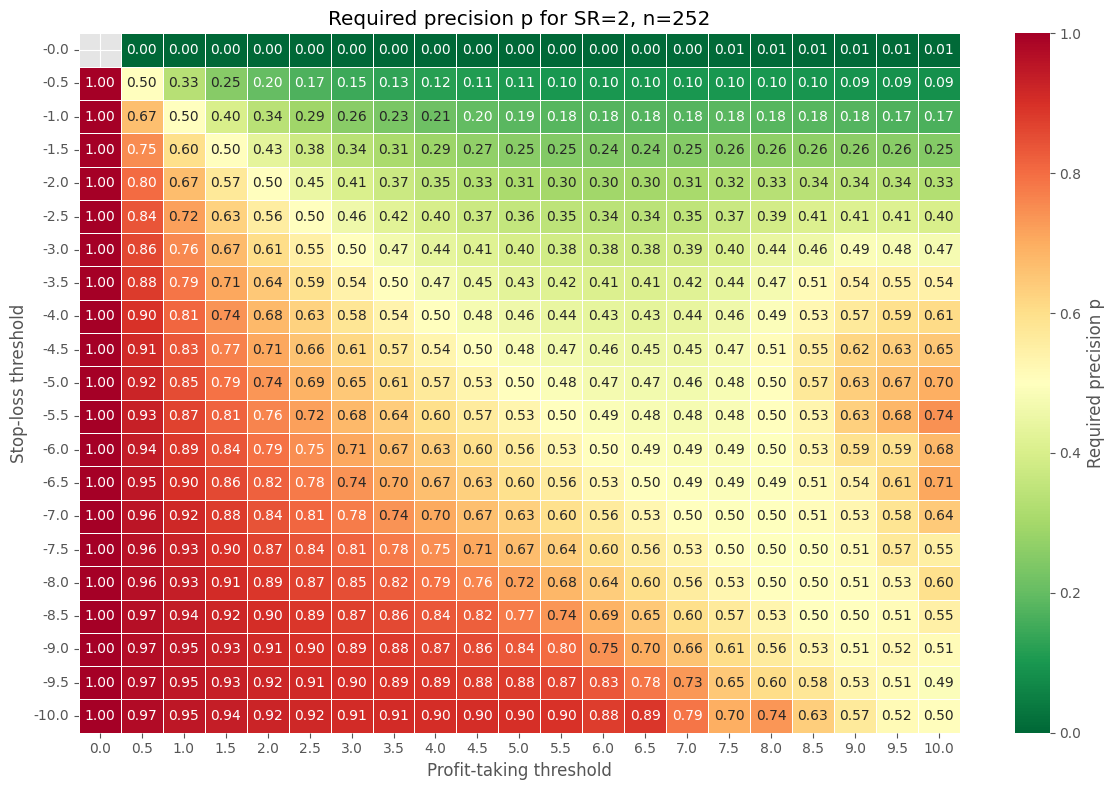

In [17]:
p_df = pd.DataFrame(pt_sl_pairs, columns=["profit_taking", "stop_loss"])
p_df["p"] = p_list

p_heatmap = p_df.pivot(
    index="stop_loss",
    columns="profit_taking",
    values="p",
).sort_index(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    p_heatmap,
    ax=ax,
    cmap="RdYlGn_r",
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Required precision p"},
)

ax.set_title("Required precision p for SR=2, n=252")
ax.set_xlabel("Profit-taking threshold")
ax.set_ylabel("Stop-loss threshold")
plt.tight_layout()
plt.show()

### c. What is the range of p implied by Figure 13.5, for a weekly betting frequency?

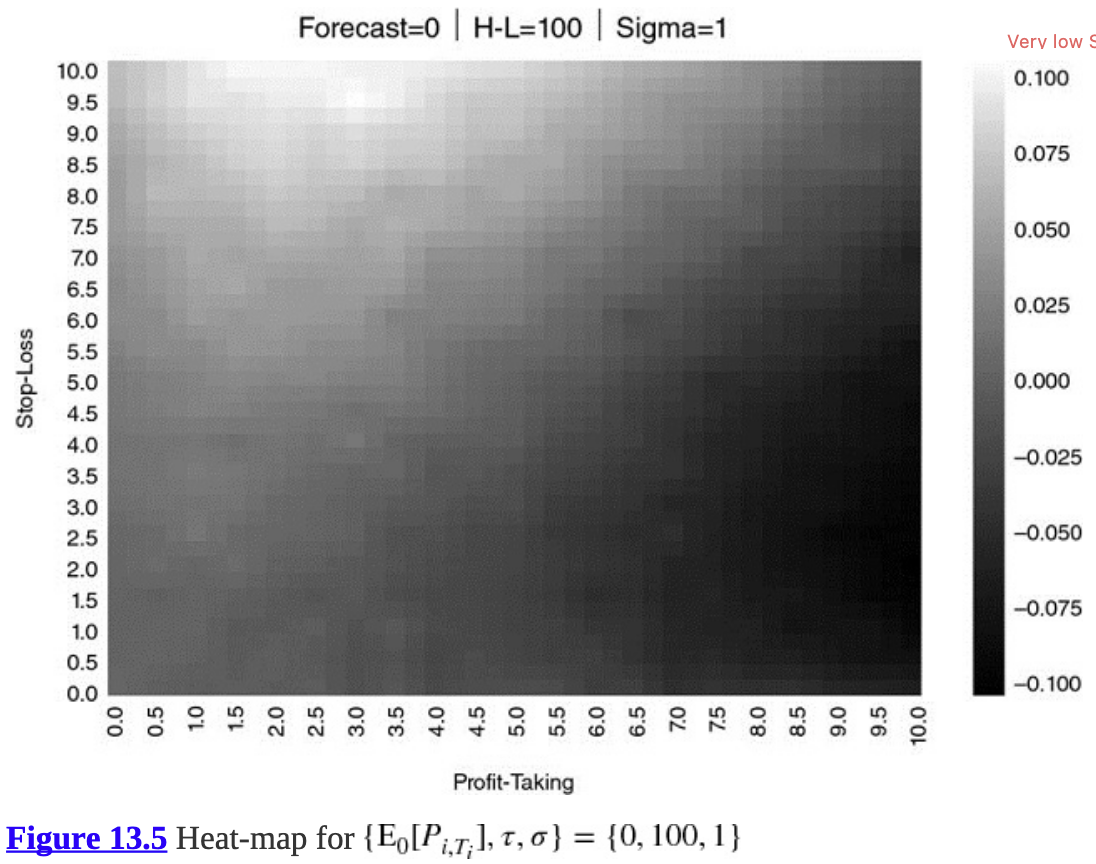

In [18]:
display(Image(filename='fig_13_5.png', width=600))

In [19]:
n = 52

coeffs = {
    "hl": 100,
    "forecast": 0,
    "sigma": 1,
}
results = simulate_ou_process(coeffs, iterations=1e5, max_hp=100, r_pt=pt_ranges, r_slm=sl_ranges, seed=0)
sr_results = [res[-1] for res in results]

Sweep (r_pt, r_slm) pairs: 100%|██████████| 441/441 [06:12<00:00,  1.18it/s]


In [21]:
p_list = []
pt_sl_pairs = []

for i, comb_ in enumerate(product(pt_ranges, sl_ranges)):
    new_p = asymmetric_precision(sr_results[i], n, comb_[0], -comb_[1])
    if not np.isnan(new_p):
        p_list.append(new_p)
        pt_sl_pairs.append((comb_[0], -comb_[1]))
    else:
        print(f"The precision is NaN for pt = {comb_[0]} and sl = {-comb_[1]}")

lowest_p = np.min(p_list)
lowest_p_index = p_list.index(lowest_p)
highest_p = np.max(p_list)
highest_p_index = p_list.index(highest_p)

print(f"The range of p implied by Figure 13.5, for a weekly betting frequency, is {lowest_p} to {highest_p}")
print(f"The corresponding pt and sl values are {(pt_sl_pairs[lowest_p_index])} and {pt_sl_pairs[highest_p_index]}")

The precision is NaN for pt = 0.0 and sl = -0.0
The range of p implied by Figure 13.5, for a weekly betting frequency, is 8.291297240278642e-09 to 1.0000000016736912
The corresponding pt and sl values are (np.float64(1.0), np.float64(-0.0)) and (np.float64(0.0), np.float64(-1.0))


/var/folders/jz/5x8l_3b512v8q13q14lhl6nc0000gn/T/ipykernel_57524/3301175551.py:12: RuntimeWarning: invalid value encountered in scalar divide
  return (-b + np.sqrt(b ** 2 - 4 * a * c)) / (2 * a)


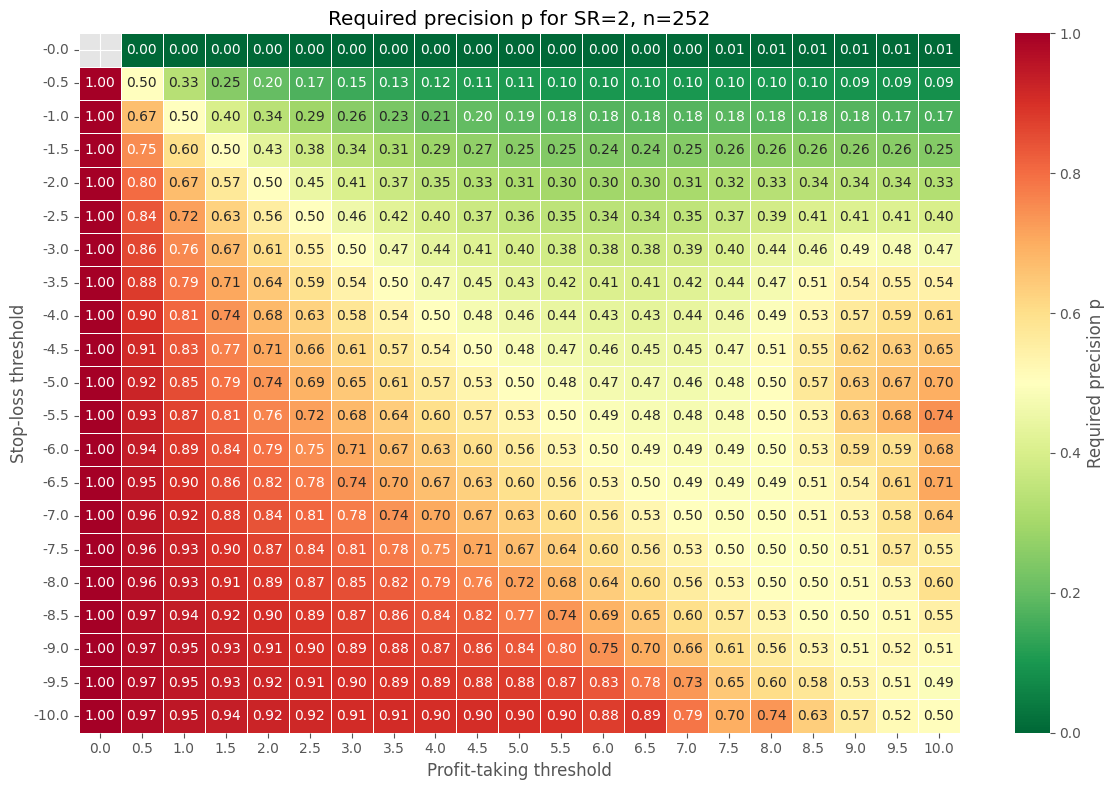

In [20]:
p_df = pd.DataFrame(pt_sl_pairs, columns=["profit_taking", "stop_loss"])
p_df["p"] = p_list

p_heatmap = p_df.pivot(
    index="stop_loss",
    columns="profit_taking",
    values="p",
).sort_index(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    p_heatmap,
    ax=ax,
    cmap="RdYlGn_r",
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Required precision p"},
)

ax.set_title("Required precision p for SR=2, n=252")
ax.set_xlabel("Profit-taking threshold")
ax.set_ylabel("Stop-loss threshold")
plt.tight_layout()
plt.show()